# Paired far-field SRP-PHAT validation

This notebook audits and visualizes the full paired common-random-number comparison of reference-3 GCC+WLS, all-6 equal GCC+WLS, all-6 calibrated GCC+WLS, and equal-weight all-6 SRP-PHAT. The full CSV is regenerated by `run_srp_statistical_validation()` only after deterministic and smoke gates pass; notebook execution then verifies that accepted artifact without silently launching another 297000-trial run. Calibration and evaluation seeds are separate. The three synthetic signal classes and AWGN are diagnostics, not a measured UAV/noise model. Reflections, wind, motion, SRP-Harmonics, and GCC confidence weights inside SRP are excluded.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

from validation.srp_statistical import (
    SRP_CALIBRATION_TRIAL_COUNT, SRP_EVALUATION_TRIAL_COUNT,
    SRP_EXACT_REFERENCE_TRIALS, SRP_METHODS, SRP_SEARCH_STEPS_DEG,
    SRP_STATISTICAL_BASE_SEED,
)
plt.rcParams.update({'figure.figsize': (8, 4.8), 'axes.grid': True})
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
print('project root:', PROJECT_ROOT)
print('seed:', SRP_STATISTICAL_BASE_SEED)
print('calibration/evaluation:', SRP_CALIBRATION_TRIAL_COUNT, SRP_EVALUATION_TRIAL_COUNT)
print('SRP grid steps, deg:', SRP_SEARCH_STEPS_DEG)

project root: C:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model
seed: 20260829
calibration/evaluation: 500 1000
SRP grid steps, deg: (5.0, 1.0, 0.25)


## Full paired Monte Carlo artifact

The accepted CSV was generated by `run_srp_statistical_validation()`. Every method in an evaluation trial receives the same noisy four-channel frame. The first exact-reference trials per configuration independently check the accelerated correlation-interpolation search.

In [2]:
with (PROJECT_ROOT / 'results/srp_doa_summary.csv').open(encoding='utf-8', newline='') as stream:
    doa_rows = list(csv.DictReader(stream))
with (PROJECT_ROOT / 'results/srp_runtime_summary.csv').open(encoding='utf-8', newline='') as stream:
    runtime_rows = list(csv.DictReader(stream))
assert len(doa_rows) == 792 and len(runtime_rows) == 594
keys = ('geometry', 'signal_model', 'direction', 'snr_db')
groups = defaultdict(list)
for row in doa_rows:
    groups[tuple(row[k] for k in keys)].append(row)
assert len(groups) == 198
assert all({r['estimator_variant'] for r in rows} == set(SRP_METHODS) for rows in groups.values())
assert all(len({r['evaluation_seed'] for r in rows}) == 1 for rows in groups.values())
assert all(r['evaluation_seed'] != r['calibration_seed'] for r in doa_rows)
assert all(int(r['successful_trial_count']) + int(r['unsuccessful_trial_count']) == SRP_EVALUATION_TRIAL_COUNT for r in doa_rows)
assert all(float(r['conditional_p95_geodesic_error_deg']) <= float(r['conditional_p99_geodesic_error_deg']) <= float(r['conditional_p999_geodesic_error_deg']) for r in doa_rows)
print('configurations/trials:', len(groups), len(groups) * (SRP_CALIBRATION_TRIAL_COUNT + SRP_EVALUATION_TRIAL_COUNT))
print('DOA/runtime rows:', len(doa_rows), len(runtime_rows))

configurations/trials: 198 297000
DOA/runtime rows: 792 594


## Accuracy and tails versus SNR

Curves are means over the three directions. Conditional metrics describe successful estimates; coverage is plotted separately. No requirement that SRP outperform GCC+WLS is imposed.

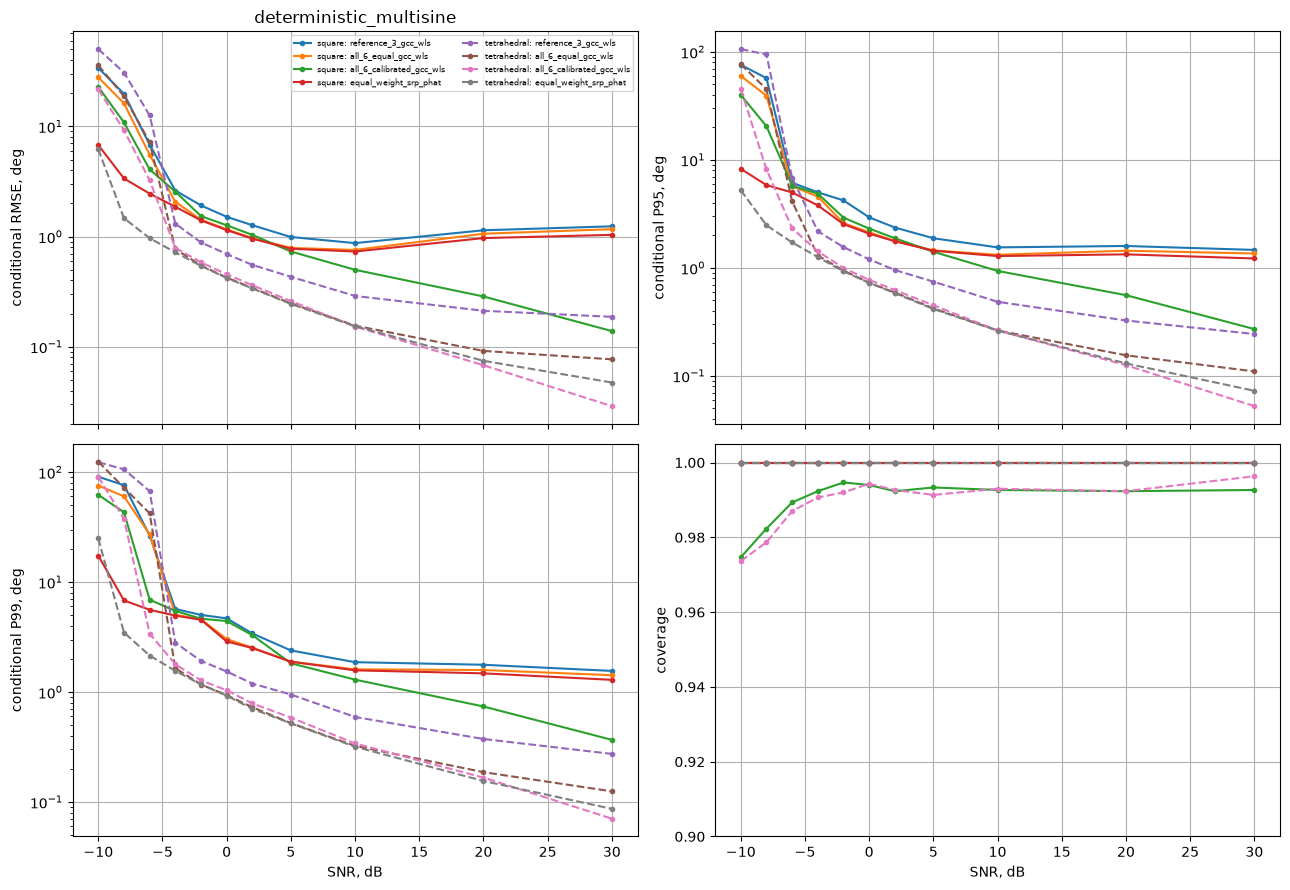

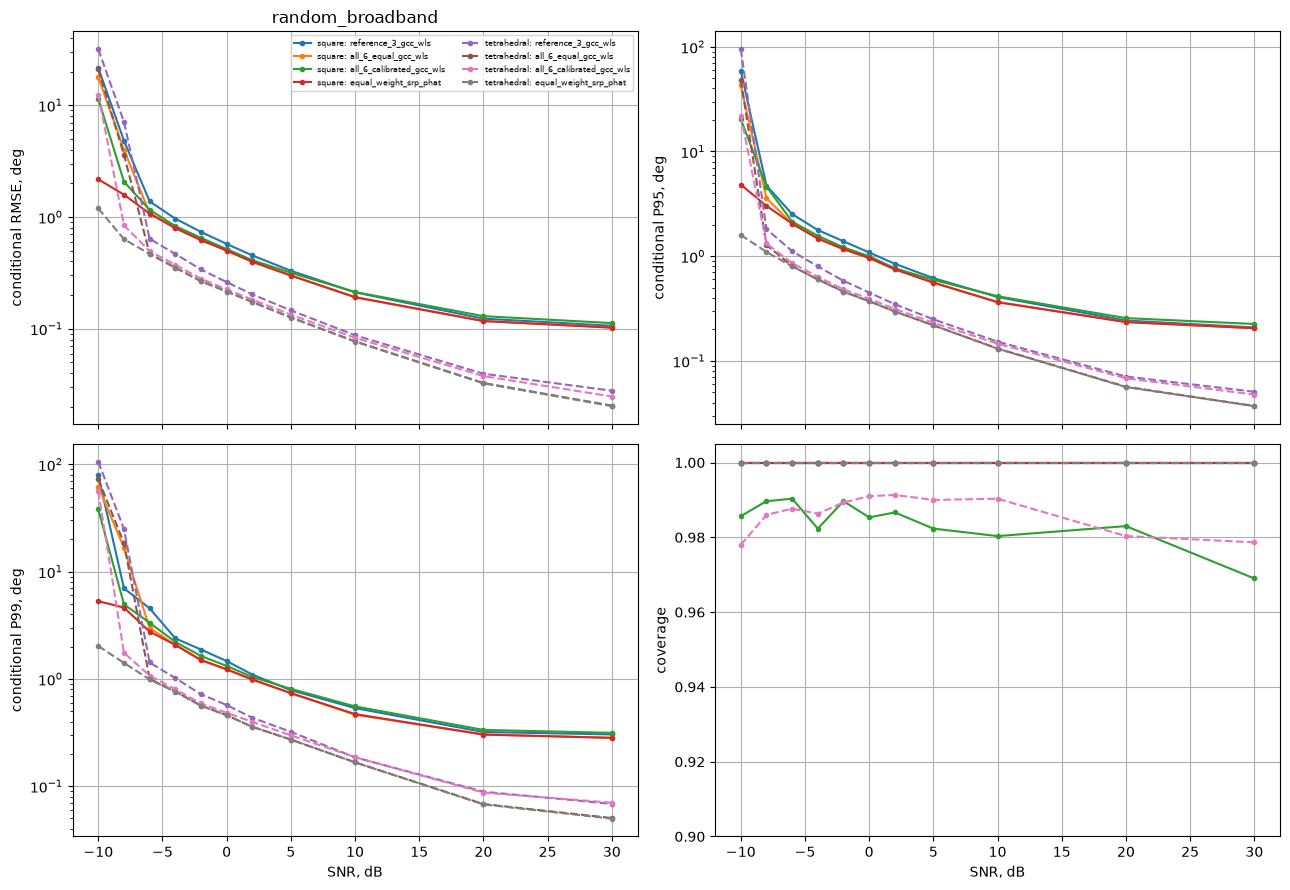

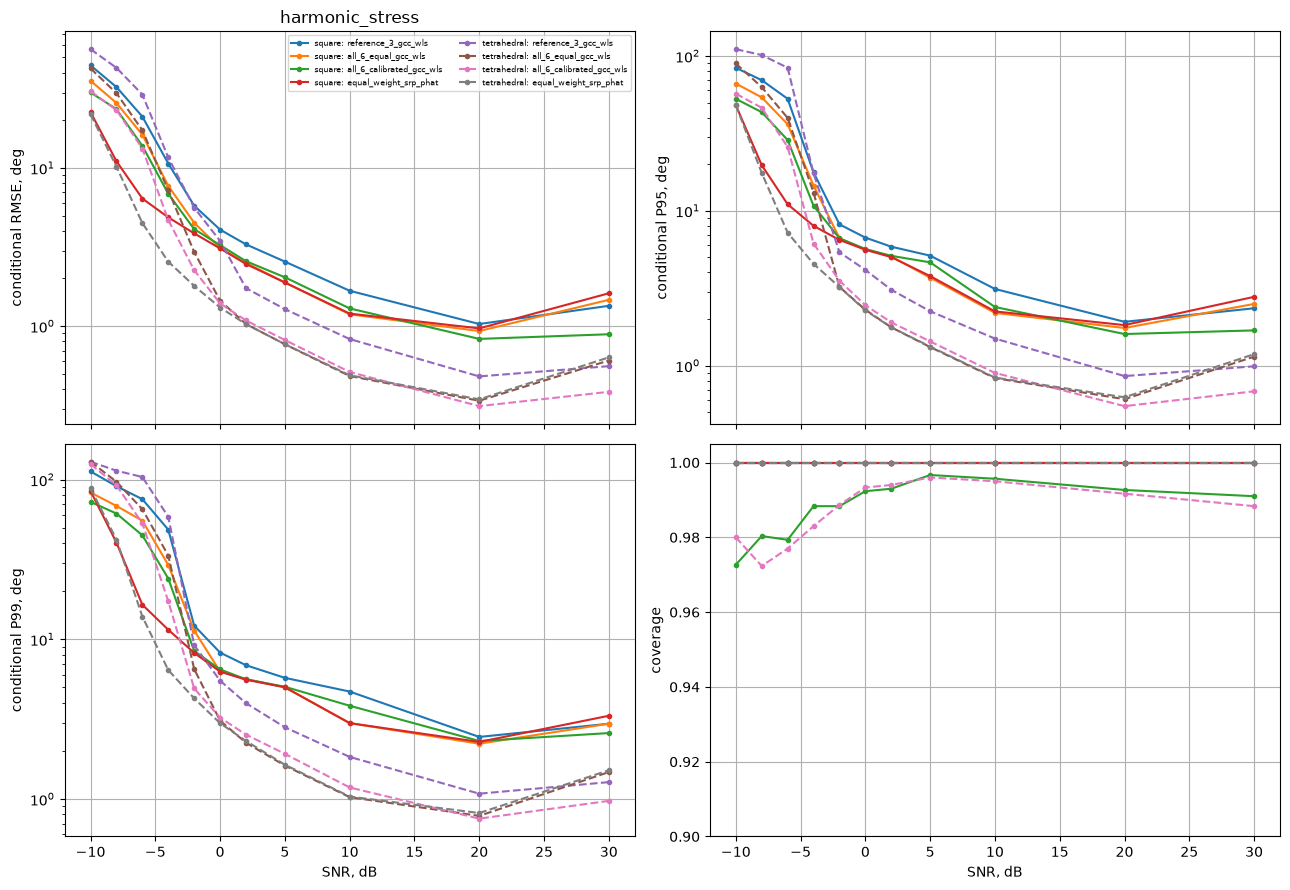

In [3]:
def aggregate(geometry, signal, method, snr, field):
    values = [float(r[field]) for r in doa_rows if r['geometry'] == geometry and r['signal_model'] == signal and r['estimator_variant'] == method and float(r['snr_db']) == snr]
    return float(np.mean(values))
snrs = sorted({float(r['snr_db']) for r in doa_rows})
for signal in ('deterministic_multisine', 'random_broadband', 'harmonic_stress'):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    for geometry, linestyle in (('square', '-'), ('tetrahedral', '--')):
        for method in SRP_METHODS:
            label = f'{geometry}: {method}'
            axes[0, 0].semilogy(snrs, [aggregate(geometry, signal, method, s, 'conditional_geodesic_rmse_deg') for s in snrs], linestyle, marker='o', ms=3, label=label)
            axes[0, 1].semilogy(snrs, [aggregate(geometry, signal, method, s, 'conditional_p95_geodesic_error_deg') for s in snrs], linestyle, marker='o', ms=3)
            axes[1, 0].semilogy(snrs, [aggregate(geometry, signal, method, s, 'conditional_p99_geodesic_error_deg') for s in snrs], linestyle, marker='o', ms=3)
            axes[1, 1].plot(snrs, [aggregate(geometry, signal, method, s, 'successful_fraction') for s in snrs], linestyle, marker='o', ms=3)
    axes[0, 0].set(ylabel='conditional RMSE, deg', title=signal)
    axes[0, 1].set(ylabel='conditional P95, deg')
    axes[1, 0].set(xlabel='SNR, dB', ylabel='conditional P99, deg')
    axes[1, 1].set(xlabel='SNR, dB', ylabel='coverage', ylim=(0.9, 1.005))
    axes[0, 0].legend(fontsize=6, ncol=2); plt.tight_layout(); plt.show()

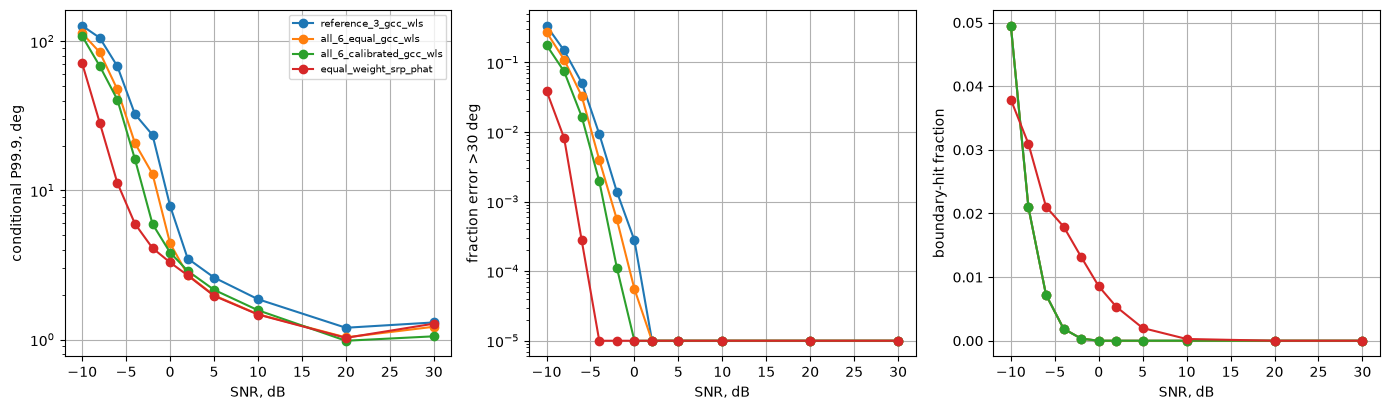

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for method in SRP_METHODS:
    rows = [r for r in doa_rows if r['estimator_variant'] == method]
    axes[0].semilogy(snrs, [max(np.mean([float(r['conditional_p999_geodesic_error_deg']) for r in rows if float(r['snr_db']) == s]), 1e-4) for s in snrs], 'o-', label=method)
    axes[1].semilogy(snrs, [max(np.mean([float(r['fraction_error_gt_30deg']) for r in rows if float(r['snr_db']) == s]), 1e-5) for s in snrs], 'o-')
    axes[2].plot(snrs, [np.mean([float(r['boundary_hit_fraction']) for r in rows if float(r['snr_db']) == s]) for s in snrs], 'o-')
axes[0].set(xlabel='SNR, dB', ylabel='conditional P99.9, deg')
axes[1].set(xlabel='SNR, dB', ylabel='fraction error >30 deg')
axes[2].set(xlabel='SNR, dB', ylabel='boundary-hit fraction')
axes[0].legend(fontsize=7); plt.tight_layout(); plt.show()

## Paired comparison and accelerated-reference audit

In [5]:
paired = {key: {r['estimator_variant']: r for r in rows} for key, rows in groups.items()}
for metric in ('conditional_geodesic_rmse_deg', 'conditional_p95_geodesic_error_deg', 'conditional_p99_geodesic_error_deg'):
    print(metric)
    for method in SRP_METHODS[:-1]:
        wins = sum(float(rows['equal_weight_srp_phat'][metric]) < float(rows[method][metric]) for rows in paired.values())
        print('  SRP lower than', method, ':', wins, '/', len(paired))
exact_rows = [r for r in runtime_rows if r['runtime_component'] == 'srp_exact_vectorized_reference']
assert sum(int(r['exact_reference_trial_count']) for r in runtime_rows) == len(groups) * SRP_EXACT_REFERENCE_TRIALS
assert all(int(r['exact_reference_trial_count']) == 0 for r in runtime_rows if r['runtime_component'] != 'srp_exact_vectorized_reference')
assert all(r['exact_fast_disagreement_covers_all_evaluation_trials'] == 'False' for r in runtime_rows)
max_disagreement = max(float(r['max_exact_fast_disagreement_deg']) for r in exact_rows)
print('unique sampled exact trials / maximum sampled angular disagreement, deg:', sum(int(r['exact_reference_trial_count']) for r in runtime_rows), max_disagreement)
print('scope: first 3 evaluation trials/config only; not all evaluation trials')
for component in sorted({r['runtime_component'] for r in runtime_rows}):
    rows = [r for r in runtime_rows if r['runtime_component'] == component]
    print(component, 'mean seconds/estimate:', np.mean([float(r['mean_runtime_s']) for r in rows]))

conditional_geodesic_rmse_deg
  SRP lower than reference_3_gcc_wls : 191 / 198
  SRP lower than all_6_equal_gcc_wls : 166 / 198
  SRP lower than all_6_calibrated_gcc_wls : 168 / 198
conditional_p95_geodesic_error_deg
  SRP lower than reference_3_gcc_wls : 190 / 198
  SRP lower than all_6_equal_gcc_wls : 153 / 198
  SRP lower than all_6_calibrated_gcc_wls : 166 / 198
conditional_p99_geodesic_error_deg
  SRP lower than reference_3_gcc_wls : 189 / 198
  SRP lower than all_6_equal_gcc_wls : 142 / 198
  SRP lower than all_6_calibrated_gcc_wls : 165 / 198
unique sampled exact trials / maximum sampled angular disagreement, deg: 594 0.0313649563259267
scope: first 3 evaluation trials/config only; not all evaluation trials
gcc_all_pair_phat mean seconds/estimate: 0.0009952510868465514
srp_exact_vectorized_reference mean seconds/estimate: 0.25348474158315926
srp_interpolated_search mean seconds/estimate: 0.004127070375790201


In [6]:
for path, expected in ((PROJECT_ROOT / 'results/srp_doa_summary.csv', 792), (PROJECT_ROOT / 'results/srp_runtime_summary.csv', 594)):
    assert path.exists()
    with path.open(encoding='utf-8', newline='') as stream:
        assert sum(1 for _ in csv.DictReader(stream)) == expected
assert all(r['equal_pair_weights'] == 'True' and r['gcc_confidence_used_by_srp'] == 'False' for r in doa_rows if r['estimator_variant'] == 'equal_weight_srp_phat')
assert not any(np.isnan(float(r['conditional_geodesic_rmse_deg'])) for r in doa_rows)
print('All paired SRP numerical and artifact checks passed.')

All paired SRP numerical and artifact checks passed.
